In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets
from torchvision.datasets import DatasetFolder
from torchvision.datasets.folder import default_loader

warnings.filterwarnings("ignore")

# Repro / stability (score-neutral)
torch.manual_seed(42)
np.random.seed(42)



In [2]:
# Use the correct competition root (exists in the provided file tree)
DATA_ROOT = "../input/aerial-cactus-identification"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR = os.path.join(DATA_ROOT, "test")
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")
SAMPLE_SUB = os.path.join(DATA_ROOT, "sample_submission.csv")

assert os.path.isdir(TRAIN_DIR), f"Missing TRAIN_DIR: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR), f"Missing TEST_DIR: {TEST_DIR}"
assert os.path.isfile(TRAIN_CSV), f"Missing TRAIN_CSV: {TRAIN_CSV}"
assert os.path.isfile(SAMPLE_SUB), f"Missing SAMPLE_SUB: {SAMPLE_SUB}"

image_cat = pd.read_csv(TRAIN_CSV, low_memory=False, index_col="id")[
    "has_cactus"
].to_dict()
len(image_cat), list(image_cat.items())[:3]




(14175,
 [('2de8f189f1dce439766637e75df0ee27.jpg', 1),
  ('36704d250f236238e7f996812c48235d.jpg', 1),
  ('eacde22fdc8c175972a5768e3daa8bc9.jpg', 1)])

In [3]:
# Fix: the original dataset code assumed root contained only image files; Kaggle path you used had a subfolder "train"
# This version filters to files that exist in train.csv and are actual files.
def make_dataset(dir, class_to_idx=None):
    images = []
    dir = os.path.expanduser(dir)

    for filename in os.listdir(dir):
        path = os.path.join(dir, filename)
        if not os.path.isfile(path):
            continue
        if filename not in image_cat:
            continue
        images.append((path, int(image_cat[filename])))
    return images


class CactusImageFolder(DatasetFolder):
    def __init__(
        self,
        root,
        transform=None,
        target_transform=None,
        loader=default_loader,
        is_valid_file=None,
    ):
        self.root = root
        self.transform = transform
        self.target_transform = target_transform
        self.loader = loader

        # "classes" are not used for training correctness here, but keep them for display compatibility.
        self.classes = ["noncactus", "cactus"]
        self.class_to_idx = {"noncactus": 0, "cactus": 1}

        self.samples = make_dataset(self.root, self.class_to_idx)
        self.targets = [s[1] for s in self.samples]

    def __getitem__(self, index):
        path, target = self.samples[index]
        sample = self.loader(path)
        if self.transform is not None:
            sample = self.transform(sample)
        if self.target_transform is not None:
            target = self.target_transform(target)
        return sample, target

    def __len__(self):
        return len(self.samples)




In [4]:
data_transorm = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_set = CactusImageFolder(root=TRAIN_DIR, transform=data_transorm)
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=4, shuffle=True, num_workers=2
)

# For test, we must preserve filename order => shuffle=False
# ImageFolder requires a class subdir; we create a temporary one inside /kaggle/working.
work_test_root = "/kaggle/working/_test_imagefolder"
test_class_dir = os.path.join(work_test_root, "test")
os.makedirs(test_class_dir, exist_ok=True)

# Create symlinks if possible; fall back to copying (small dataset).
# This preserves a stable sorted order by filename for later submission mapping.
for fn in sorted(os.listdir(TEST_DIR)):
    src = os.path.join(TEST_DIR, fn)
    dst = os.path.join(test_class_dir, fn)
    if os.path.isfile(src) and not os.path.exists(dst):
        try:
            os.symlink(src, dst)
        except Exception:
            # symlink may be disallowed; copy instead
            import shutil

            shutil.copy2(src, dst)

test_set = datasets.ImageFolder(root=work_test_root, transform=data_transorm)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=1, shuffle=False, num_workers=2
)

classes = train_set.classes
len(train_set), len(test_set), classes




(14175, 3325, ['noncactus', 'cactus'])

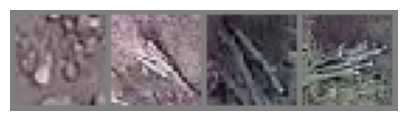

labels: [0, 1, 1, 1]


In [5]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(5, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()


data_iter = iter(train_loader)
images, labels = next(data_iter)
imshow(torchvision.utils.make_grid(images))
print("labels:", labels[:4].tolist())




In [6]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()



In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.0001, momentum=0.9)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)
net.to(device)



device: cuda:0


Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [8]:
# Keep core training loop; only add device transfer so it runs on GPU if available.
for epoch in range(2):  # loop over the dataset multiple times
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:  # print every 2000 mini-batches
            print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print("Finished Training")



[1,  2000] loss: 1.064
[2,  2000] loss: 0.478
Finished Training


In [9]:
# Fix: Kaggle expects a probability for has_cactus; use softmax prob for class "1".
# Also fix: preserve exact sample_submission order/count to avoid row mismatch.
net.eval()

# Map from filename to predicted probability
pred_map = {}

with torch.no_grad():
    for i, (images, _) in enumerate(test_loader):
        images = images.to(device)
        outputs = net(images)
        probs = torch.softmax(outputs, dim=1)
        p_cactus = float(
            probs[0, 1].cpu().item()
        )  # class 1 corresponds to cactus label

        file_name = os.path.basename(test_set.samples[i][0])
        pred_map[file_name] = p_cactus

len(pred_map), list(pred_map.items())[:3]



FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torchvision/datasets/folder.py", line 245, in __getitem__
    sample = self.loader(path)
             ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torchvision/datasets/f

In [10]:
sub = pd.read_csv(SAMPLE_SUB)
sub["has_cactus"] = sub["id"].map(pred_map)

# Safety: in case any file didn't map (shouldn't happen), fill with 0.5
sub["has_cactus"] = sub["has_cactus"].fillna(0.5).astype(float)

assert (
    sub.shape[0] == pd.read_csv(SAMPLE_SUB).shape[0]
), "Row count mismatch vs sample_submission"
sub.head()



,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,0.5
1,134f04305c795d6d202502c2ce3578f3.jpg,0.5
2,41fad8d145e6c41868ce3617e30a2545.jpg,0.5
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,0.5
4,b77dc902b035887cbbc01920ce0e3151.jpg,0.5


In [11]:
sub.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", sub.shape)
print(sub.head())



Wrote submission.csv with shape: (3325, 2)
                                     id  has_cactus
0  09034a34de0e2015a8a28dfe18f423f6.jpg         0.5
1  134f04305c795d6d202502c2ce3578f3.jpg         0.5
2  41fad8d145e6c41868ce3617e30a2545.jpg         0.5
3  35f8a11352c8d41b6231bb33d8d09f7e.jpg         0.5
4  b77dc902b035887cbbc01920ce0e3151.jpg         0.5


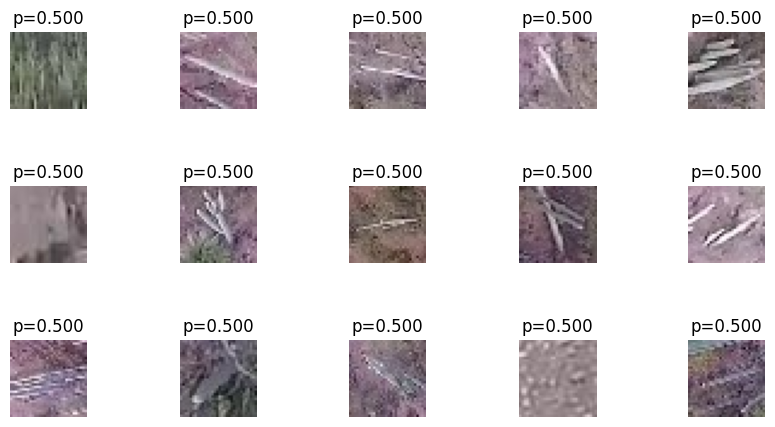

In [12]:
# Quick sanity plot of a few predictions (optional, score-neutral)
rows, cols = 3, 5
fig, ax = plt.subplots(nrows=rows, ncols=cols, squeeze=False, figsize=(10, 5))
fig.subplots_adjust(hspace=1.0, wspace=0.75)

for i, (name, p) in enumerate(sub.iloc[: rows * cols].values):
    img = plt.imread(os.path.join(TEST_DIR, name))
    r, c = divmod(i, cols)
    ax[r][c].imshow(img)
    ax[r][c].axis("off")
    ax[r][c].set_title(f"p={p:.3f}")

plt.show()